# 06 — Walk-Forward Validation

Testa se le strategie funzionano davvero out-of-sample.

**Il problema del backtest in-sample**: ottimizzare e valutare sugli stessi dati sovrastima sempre la performance. Questo notebook simula quello che avresti fatto nel tempo reale.

**Struttura:**
1. Setup e funzioni di ottimizzazione
2. Walk-Forward per Max Sharpe, Risk Parity, Min Variance
3. Confronto in-sample vs out-of-sample
4. Stabilità dei pesi nel tempo
5. Report finale

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.estimators.returns import historical_mean
from src.estimators.covariance import ledoit_wolf_covariance
from src.optimizers.markowitz import maximum_sharpe, minimum_variance
from src.optimizers.risk_parity import risk_parity
from src.backtesting.walk_forward import walk_forward_backtest, compare_in_vs_out_of_sample
from config import *

returns = pd.read_csv('../data/returns.csv', index_col=0, parse_dates=True)
print(f'Returns loaded: {returns.shape}')
print(f'Period: {returns.index[0].date()} → {returns.index[-1].date()}')

Returns loaded: (149, 8)
Period: 2014-02-01 → 2026-06-01


## 1. Funzioni di Ottimizzazione per il Walk-Forward

Ogni funzione prende in input una finestra di ritorni e restituisce i pesi ottimali.

In [2]:
def opt_max_sharpe(returns_window: pd.DataFrame) -> pd.Series:
    mu  = historical_mean(returns_window)
    cov = ledoit_wolf_covariance(returns_window)
    tickers = list(returns_window.columns)
    equity_idx = [tickers.index(t) for t in EQUITY_TICKERS if t in tickers]
    bond_idx   = [tickers.index(t) for t in BOND_TICKERS   if t in tickers]
    alt_idx    = [tickers.index(t) for t in ALT_TICKERS     if t in tickers]
    result = maximum_sharpe(
        mu, cov, RISK_FREE_RATE_ANNUAL, MIN_WEIGHT, MAX_WEIGHT,
        equity_idx=equity_idx, bond_idx=bond_idx, alt_idx=alt_idx,
        max_equity=MAX_EQUITY, max_bonds=MAX_BONDS, max_alts=MAX_ALTS,
    )
    return result.weights

def opt_risk_parity(returns_window: pd.DataFrame) -> pd.Series:
    mu  = historical_mean(returns_window)
    cov = ledoit_wolf_covariance(returns_window)
    result = risk_parity(mu, cov, RISK_FREE_RATE_ANNUAL)
    return result.weights

def opt_min_variance(returns_window: pd.DataFrame) -> pd.Series:
    mu  = historical_mean(returns_window)
    cov = ledoit_wolf_covariance(returns_window)
    tickers = list(returns_window.columns)
    equity_idx = [tickers.index(t) for t in EQUITY_TICKERS if t in tickers]
    bond_idx   = [tickers.index(t) for t in BOND_TICKERS   if t in tickers]
    alt_idx    = [tickers.index(t) for t in ALT_TICKERS     if t in tickers]
    result = minimum_variance(
        mu, cov, RISK_FREE_RATE_ANNUAL, MIN_WEIGHT, MAX_WEIGHT,
        equity_idx=equity_idx, bond_idx=bond_idx, alt_idx=alt_idx,
        max_equity=MAX_EQUITY, max_bonds=MAX_BONDS, max_alts=MAX_ALTS,
    )
    return result.weights

print('Funzioni di ottimizzazione definite ✓')

Funzioni di ottimizzazione definite ✓


## 2. Walk-Forward Backtest

**Parametri:**
- Training window: 60 mesi (5 anni)
- Test window: 12 mesi (ribilanciamento annuale)
- Prima ottimizzazione: mese 36

In [3]:
print('Running Walk-Forward backtests...')
print('(ogni strategia richiede ~10-20 secondi)\n')

wf_sharpe = walk_forward_backtest(
    returns, opt_max_sharpe,
    train_window=60, test_window=12, min_train=36
)
print(f'Max Sharpe: {len(wf_sharpe["rebalance_dates"])} ribilanciamenti ✓')

wf_rp = walk_forward_backtest(
    returns, opt_risk_parity,
    train_window=60, test_window=12, min_train=36
)
print(f'Risk Parity: {len(wf_rp["rebalance_dates"])} ribilanciamenti ✓')

wf_mv = walk_forward_backtest(
    returns, opt_min_variance,
    train_window=60, test_window=12, min_train=36
)
print(f'Min Variance: {len(wf_mv["rebalance_dates"])} ribilanciamenti ✓')

print('\nWalk-Forward completato!')

Running Walk-Forward backtests...
(ogni strategia richiede ~10-20 secondi)

Max Sharpe: 9 ribilanciamenti ✓
Risk Parity: 9 ribilanciamenti ✓
Min Variance: 9 ribilanciamenti ✓

Walk-Forward completato!


## 3. Confronto In-Sample vs Out-of-Sample

In [4]:
# Calcola performance in-sample sullo stesso periodo del walk-forward
oos_start = wf_sharpe['returns'].index[0]
returns_trimmed = returns.loc[oos_start:]

# Portafoglio in-sample ottimizzato su tutti i dati
cov_full = ledoit_wolf_covariance(returns)
mu_full  = historical_mean(returns)
tickers  = list(returns.columns)
equity_idx = [tickers.index(t) for t in EQUITY_TICKERS if t in tickers]
bond_idx   = [tickers.index(t) for t in BOND_TICKERS   if t in tickers]
alt_idx    = [tickers.index(t) for t in ALT_TICKERS     if t in tickers]

p_sharpe_is = maximum_sharpe(
    mu_full, cov_full, RISK_FREE_RATE_ANNUAL, MIN_WEIGHT, MAX_WEIGHT,
    equity_idx=equity_idx, bond_idx=bond_idx, alt_idx=alt_idx,
    max_equity=MAX_EQUITY, max_bonds=MAX_BONDS, max_alts=MAX_ALTS,
)

is_returns_sharpe  = returns_trimmed @ p_sharpe_is.weights
oos_returns_sharpe = wf_sharpe['returns']

comparison = compare_in_vs_out_of_sample(
    is_returns_sharpe, oos_returns_sharpe, RISK_FREE_RATE_ANNUAL
)

print('Max Sharpe — In-Sample vs Out-of-Sample:')
display(comparison)
print('\n→ La differenza tra le due colonne misura il grado di overfitting')

Max Sharpe — In-Sample vs Out-of-Sample:


,In-Sample,Out-of-Sample
Ann. Return (%),12.03,11.150
Ann. Vol (%),10.60,10.230
Sharpe Ratio,0.73,0.669
Max Drawdown (%),-19.26,-21.440



→ La differenza tra le due colonne misura il grado di overfitting


## 4. Cumulative Returns Out-of-Sample

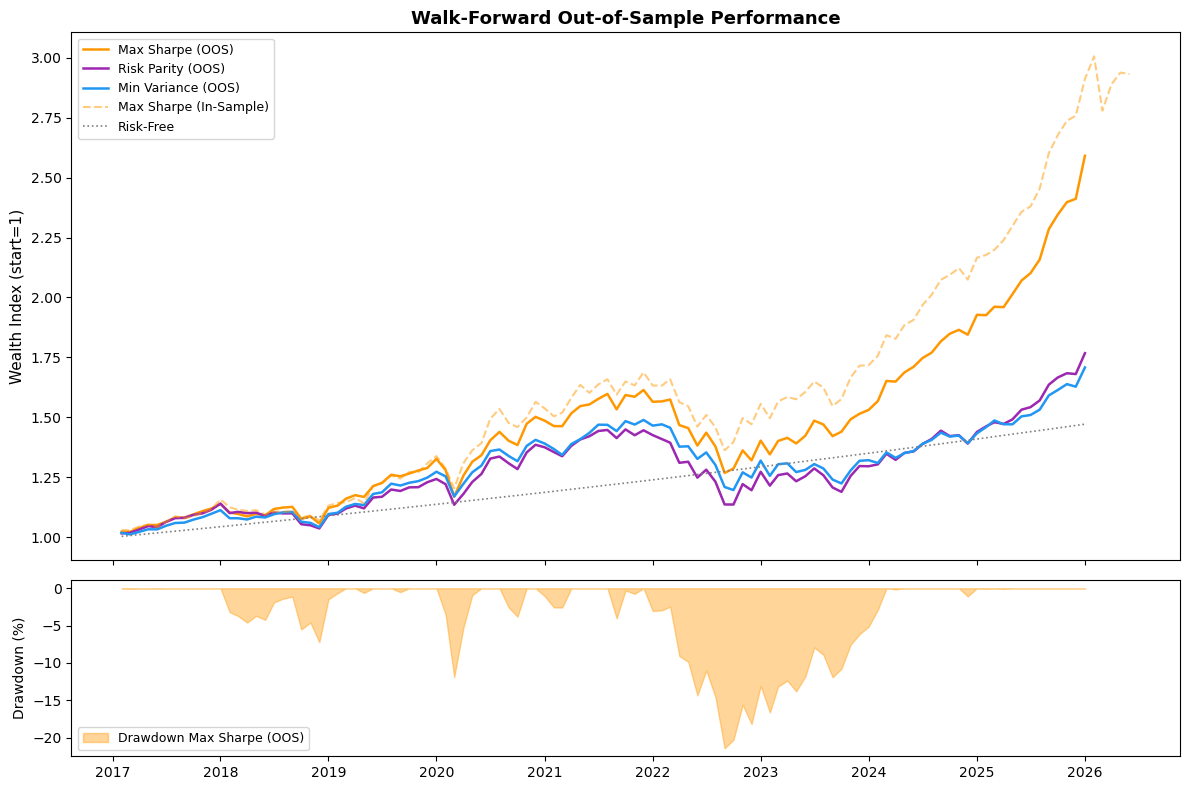

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

strategies = {
    'Max Sharpe (OOS)':   (wf_sharpe['returns'], '#FF9800'),
    'Risk Parity (OOS)':  (wf_rp['returns'],     '#9C27B0'),
    'Min Variance (OOS)': (wf_mv['returns'],      '#2196F3'),
}

for name, (ret, color) in strategies.items():
    wealth = (1 + ret).cumprod()
    axes[0].plot(wealth.index, wealth.values, lw=1.8, color=color, label=name)

# In-sample per confronto
is_wealth = (1 + is_returns_sharpe).cumprod()
axes[0].plot(is_wealth.index, is_wealth.values, '--', lw=1.5,
             color='#FF9800', alpha=0.5, label='Max Sharpe (In-Sample)')

# Risk-free
rf_monthly = RISK_FREE_RATE_ANNUAL / 12
n = len(wf_sharpe['returns'])
rf_wealth = (1 + rf_monthly) ** np.arange(1, n + 1)
axes[0].plot(wf_sharpe['returns'].index, rf_wealth, ':',
             color='gray', lw=1.2, label='Risk-Free')

axes[0].set_ylabel('Wealth Index (start=1)', fontsize=11)
axes[0].set_title('Walk-Forward Out-of-Sample Performance', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Drawdown Max Sharpe OOS
dd = (1 + wf_sharpe['returns']).cumprod()
dd = (dd / dd.cummax() - 1) * 100
axes[1].fill_between(dd.index, dd.values, 0, color='#FF9800', alpha=0.4,
                      label='Drawdown Max Sharpe (OOS)')
axes[1].set_ylabel('Drawdown (%)', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/06_walk_forward_returns.png', dpi=150)
plt.show()

## 5. Stabilità dei Pesi nel Tempo

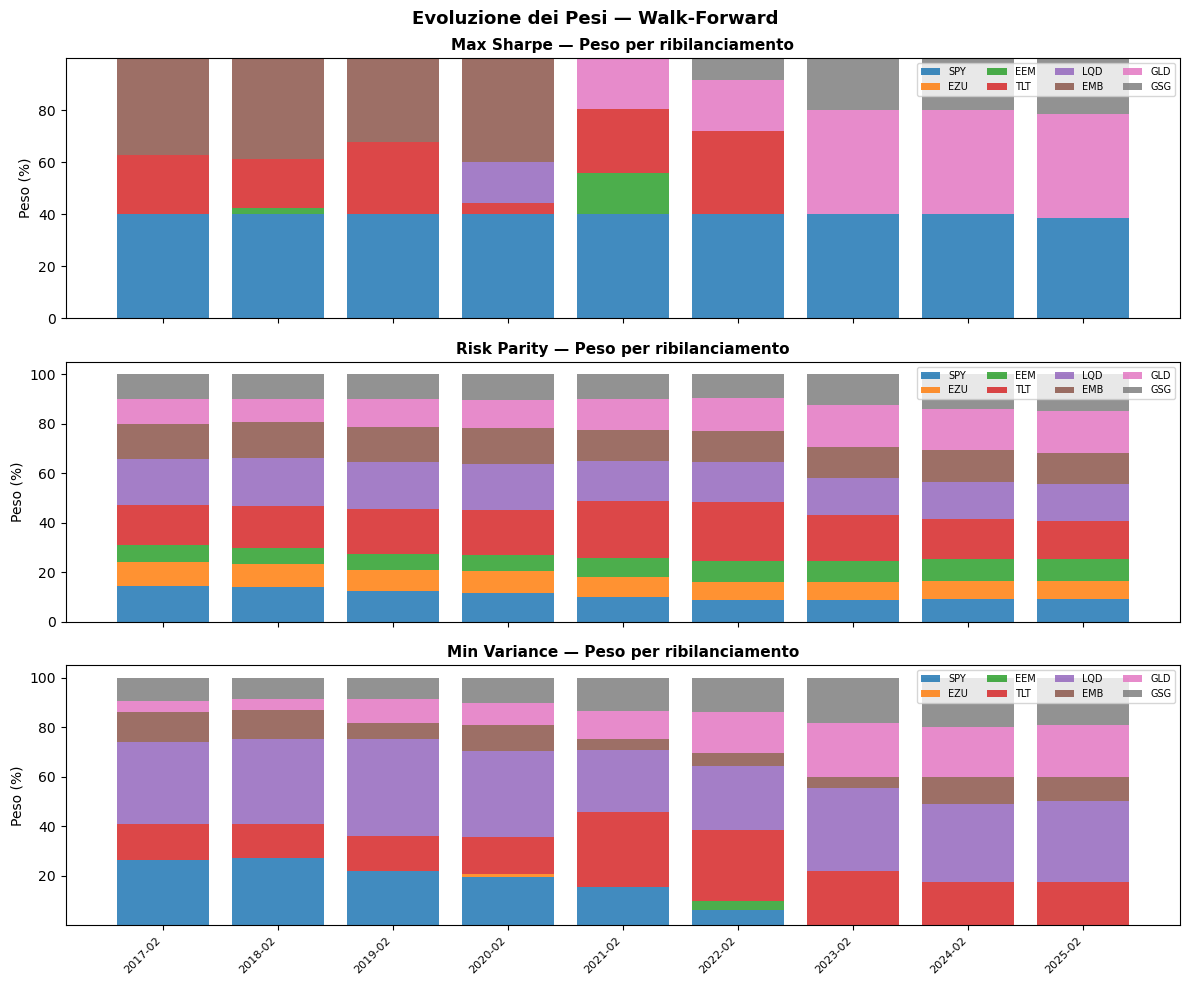

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

titles = ['Max Sharpe', 'Risk Parity', 'Min Variance']
wf_list = [wf_sharpe, wf_rp, wf_mv]
colors = plt.cm.tab10.colors

for ax, wf, title in zip(axes, wf_list, titles):
    weights_df = wf['weights'] * 100
    bottom = np.zeros(len(weights_df))
    for i, col in enumerate(weights_df.columns):
        ax.bar(range(len(weights_df)), weights_df[col],
               bottom=bottom, label=col, color=colors[i], alpha=0.85)
        bottom += weights_df[col].values
    ax.set_title(f'{title} — Peso per ribilanciamento', fontsize=11, fontweight='bold')
    ax.set_ylabel('Peso (%)')
    ax.legend(loc='upper right', fontsize=7, ncol=4)
    ax.set_xticks(range(len(weights_df)))
    ax.set_xticklabels(
        [str(d)[:7] for d in weights_df.index], rotation=45, ha='right', fontsize=8
    )

plt.suptitle('Evoluzione dei Pesi — Walk-Forward', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/06_weights_evolution.png', dpi=150)
plt.show()

## 6. Report Finale — Confronto Completo

In [7]:
def compute_metrics(ret, rf=RISK_FREE_RATE_ANNUAL, freq=12):
    ann_ret = ret.mean() * freq
    ann_vol = ret.std() * np.sqrt(freq)
    sharpe  = (ann_ret - rf) / ann_vol
    dd      = ((1 + ret).cumprod() / (1 + ret).cumprod().cummax() - 1).min()
    cvar    = -ret[ret <= ret.quantile(0.05)].mean()
    return {
        'Ann. Return (%)':  round(ann_ret * 100, 2),
        'Ann. Vol (%)':     round(ann_vol * 100, 2),
        'Sharpe':           round(sharpe, 3),
        'Max DD (%)':       round(dd * 100, 2),
        'CVaR 95% (%)':     round(cvar * 100, 2),
    }

report = pd.DataFrame({
    'Max Sharpe (IS)':    compute_metrics(is_returns_sharpe),
    'Max Sharpe (OOS)':   compute_metrics(wf_sharpe['returns']),
    'Risk Parity (OOS)':  compute_metrics(wf_rp['returns']),
    'Min Variance (OOS)': compute_metrics(wf_mv['returns']),
})

print('='*65)
print('WALK-FORWARD VALIDATION — REPORT FINALE')
print('='*65)
display(report)

is_sharpe  = report.loc['Sharpe', 'Max Sharpe (IS)']
oos_sharpe = report.loc['Sharpe', 'Max Sharpe (OOS)']
degradation = (is_sharpe - oos_sharpe) / is_sharpe * 100
print(f'\nDegradazione Sharpe IS→OOS: {degradation:.1f}%')
print('(degradazione > 50% suggerisce overfitting significativo)')

report.to_csv('../results/06_walk_forward_report.csv')
print('\nReport salvato ✓')

WALK-FORWARD VALIDATION — REPORT FINALE


,Max Sharpe (IS),Max Sharpe (OOS),Risk Parity (OOS),Min Variance (OOS)
Ann. Return (%),12.03,11.150,6.780,6.330
Ann. Vol (%),10.60,10.230,9.320,8.590
Sharpe,0.73,0.669,0.266,0.236
Max DD (%),-19.26,-21.440,-21.620,-19.620
CVaR 95% (%),6.09,6.170,5.740,5.270



Degradazione Sharpe IS→OOS: 8.4%
(degradazione > 50% suggerisce overfitting significativo)

Report salvato ✓
